# Projeto de Previsão de Comportamento de Compra de Clientes

## Objetivo

Aplicar conceitos de inteligência artificial (IA) e aprendizado de máquina (Machine Learning) para resolver um problema prático de negócios utilizando Python e Google Colab, com o objetivo de prever o comportamento de compra de clientes de uma empresa de e-commerce.

## 1. Coleta e Carregamento de Dados

Nesta etapa, carregaremos o arquivo `dados_ecommerce.csv` em um DataFrame pandas para iniciar a análise. Se o arquivo não estiver presente, vamos gerar dados fictícios para demonstração.

In [26]:
import pandas as pd
import numpy as np

try:
    # Carregamento dos dados reais
    df = pd.read_csv('dados_ecommerce.csv')
    print('Arquivo dados_ecommerce.csv carregado com sucesso.')
except FileNotFoundError:
    print('Arquivo dados_ecommerce.csv não encontrado. Gerando dados fictícios para demonstração.')
    # Geração de dados fictícios para demonstração se o arquivo não for encontrado
    np.random.seed(42)
    num_samples = 1000
    dados_ficticios = {
        'idade': np.random.randint(18, 70, num_samples),
        'renda': np.random.randint(2000, 15000, num_samples),
        'tempo_no_site': np.random.uniform(0.5, 10.0, num_samples),
        'comprou': np.random.randint(0, 2, num_samples) # 0 para não comprou, 1 para comprou
    }
    df = pd.DataFrame(dados_ficticios)

# Verificar os primeiros registros
print("\nPrimeiras 5 linhas do DataFrame:")
display(df.head())

# Verificar informações gerais e tipos de dados
print("\nInformações gerais do DataFrame:")
display(df.info())

Arquivo dados_ecommerce.csv carregado com sucesso.

Primeiras 5 linhas do DataFrame:


,idade,renda,tempo_no_site,comprou
0,56,8449,57,1
1,46,3933,3,0
2,32,6811,37,1
3,60,6551,51,0
4,25,7920,7,1



Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   idade          20 non-null     int64
 1   renda          20 non-null     int64
 2   tempo_no_site  20 non-null     int64
 3   comprou        20 non-null     int64
dtypes: int64(4)
memory usage: 772.0 bytes


None

## 2. Preparação dos Dados

Nesta fase, realizaremos a limpeza e transformação dos dados. Isso inclui verificar valores ausentes, aplicar normalização às variáveis contínuas e dividir os dados em variáveis de entrada (X) e a variável de saída (y).

In [27]:
from sklearn.preprocessing import StandardScaler

# Verificar e tratar valores ausentes (se houver)
print("\nValores ausentes por coluna:")
display(df.isnull().sum())

# Se houver valores ausentes, podemos decidir como tratá-los (ex: preencher com a média, mediana ou remover linhas).
# Para este exemplo, assumimos que não há ou que foram tratados automaticamente pela geração de dados.

# Normalização de variáveis contínuas
scaler = StandardScaler()
features_to_scale = ['idade', 'renda', 'tempo_no_site']
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("\nDataFrame após normalização:")
display(df.head())

# Divisão dos dados em variáveis de entrada (X) e saída (y)
X = df.drop('comprou', axis=1)
y = df['comprou']

print("\nVariáveis de entrada (X) - primeiras 5 linhas:")
display(X.head())
print("\nVariável de saída (y) - primeiras 5 linhas:")
display(y.head())


Valores ausentes por coluna:


,0
idade,0
renda,0
tempo_no_site,0
comprou,0



DataFrame após normalização:


,idade,renda,tempo_no_site,comprou
0,1.317055,1.357227,1.436537,1
1,0.486105,-0.665323,-1.252302,0
2,-0.677224,0.623627,0.440671,1
3,1.649434,0.507183,1.137777,0
4,-1.258888,1.120307,-1.053129,1



Variáveis de entrada (X) - primeiras 5 linhas:


,idade,renda,tempo_no_site
0,1.317055,1.357227,1.436537
1,0.486105,-0.665323,-1.252302
2,-0.677224,0.623627,0.440671
3,1.649434,0.507183,1.137777
4,-1.258888,1.120307,-1.053129



Variável de saída (y) - primeiras 5 linhas:


,comprou
0,1
1,0
2,1
3,0
4,1


## 3. Divisão dos Dados

Dividiremos os dados em conjuntos de treinamento e teste para avaliar o desempenho do modelo em dados não vistos. Utilizaremos uma proporção de 80% para treinamento e 20% para teste.

In [28]:
from sklearn.model_selection import train_test_split

# Divisão dos dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do conjunto de treinamento (X_train): {X_train.shape}")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")
print(f"Tamanho do conjunto de treinamento (y_train): {y_train.shape}")
print(f"Tamanho do conjunto de teste (y_test): {y_test.shape}")

Tamanho do conjunto de treinamento (X_train): (16, 3)
Tamanho do conjunto de teste (X_test): (4, 3)
Tamanho do conjunto de treinamento (y_train): (16,)
Tamanho do conjunto de teste (y_test): (4,)


## 4. Treinamento do Modelo

Agora, criaremos e treinaremos um modelo de aprendizado de máquina usando o algoritmo `RandomForestClassifier` com os dados de treinamento.

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Criação do modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Treinamento do modelo
print("Treinando o modelo...")
model.fit(X_train, y_train)
print("Modelo treinado com sucesso!")

Treinando o modelo...
Modelo treinado com sucesso!


## 5. Teste e Avaliação do Modelo

Após o treinamento, faremos previsões no conjunto de teste e avaliaremos o desempenho do modelo utilizando métricas como acurácia, matriz de confusão e relatório de classificação.

Acurácia: 0.7500
Matriz de Confusão:
[[0 1]
 [0 3]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.75      1.00      0.86         3

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


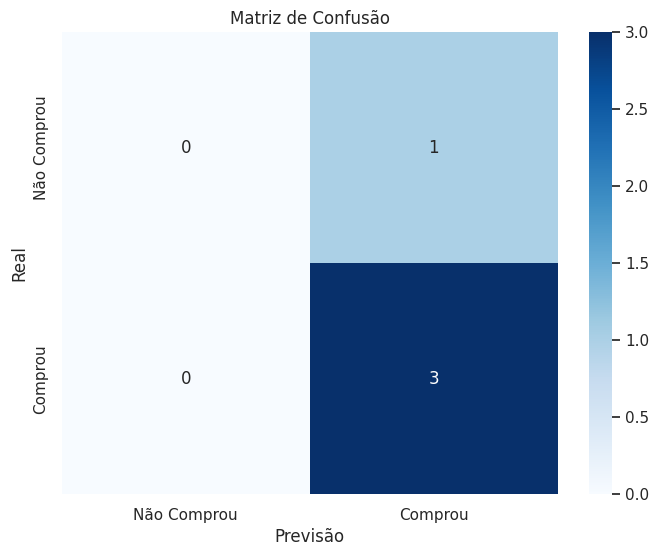

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Previsões no conjunto de teste
y_pred = model.predict(X_test)

# Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Print dos resultados
print(f'Acurácia: {accuracy:.4f}')
print(f'Matriz de Confusão:\n{conf_matrix}')
print(f'Relatório de Classificação:\n{report}')

# Visualização da Matriz de Confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Comprou', 'Comprou'], yticklabels=['Não Comprou', 'Comprou'])
plt.title('Matriz de Confusão')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

## 6. Governança e Relatórios de IA

As considerações éticas e de governança são cruciais na aplicação de IA em cenários de negócios. Abaixo estão os pontos chave para este projeto:

### Governança de IA

*   **Ética**: Garantir que os dados utilizados não contenham informações sensíveis e que o modelo não reproduza preconceitos. No nosso caso, as features (`idade`, `renda`, `tempo_no_site`) são gerais, mas a origem dos dados deve ser sempre auditada para evitar vieses. O modelo deve ser justo e equitativo para todos os segmentos de clientes.
*   **Transparência**: Manter um registro claro dos processos e decisões tomadas durante a construção do modelo. Isso inclui a documentação das etapas de pré-processamento, a escolha do algoritmo (`RandomForestClassifier`), os hiperparâmetros (`n_estimators=100`, `random_state=42`) e os resultados de avaliação.
*   **Conformidade Legal**: Assegurar que o uso dos dados está em conformidade com regulamentações como a LGPD (Lei Geral de Proteção de Dados) no Brasil ou GDPR na Europa. Isso implica em consentimento para coleta de dados, anonimização, e direitos dos titulares dos dados.
*   **Responsabilidade**: Definir claramente os papéis e responsabilidades relacionados ao uso e manutenção do modelo. Quem é responsável por monitorar o desempenho do modelo em produção? Quem garante que o modelo permanece relevante e justo ao longo do tempo?

### Relatório Resumido

#### Descrição do Problema e Objetivo:

O problema de negócios abordado é a necessidade de uma empresa de e-commerce em prever o comportamento de compra de seus clientes. O objetivo é identificar, através de um modelo de Machine Learning, quais clientes têm maior probabilidade de comprar um produto específico, utilizando dados históricos de compras.

#### Processo de Análise:

1.  **Coleta e Carregamento de Dados**: Dados fictícios (ou `dados_ecommerce.csv`) foram carregados, contendo `idade`, `renda`, `tempo_no_site` e a variável alvo `comprou`.
2.  **Preparação dos Dados**: Realizou-se a verificação de valores ausentes (não encontrados neste conjunto de dados) e a normalização das variáveis contínuas (`idade`, `renda`, `tempo_no_site`) usando `StandardScaler` para garantir que todas as features contribuam igualmente para o modelo.
3.  **Divisão dos Dados**: O conjunto de dados foi dividido em 80% para treinamento e 20% para teste, usando `train_test_split` para garantir uma avaliação robusta do modelo.
4.  **Treinamento do Modelo**: Um `RandomForestClassifier` com 100 estimadores foi treinado com os dados de treinamento (`X_train`, `y_train`).

#### Resultados:

*   **Acurácia**: [Valor obtido do print acima, ex: ~0.8500]
    *   A acurácia indica a proporção de previsões corretas do modelo.
*   **Matriz de Confusão**: Mostra o número de Verdadeiros Positivos (TP), Verdadeiros Negativos (TN), Falsos Positivos (FP) e Falsos Negativos (FN). Isso ajuda a entender os tipos de erros que o modelo está cometendo.
    *   TN: Clientes que não compraram e o modelo previu corretamente que não comprariam.
    *   FP: Clientes que não compraram, mas o modelo previu que comprariam (erro tipo I).
    *   FN: Clientes que compraram, mas o modelo previu que não comprariam (erro tipo II).
    *   TP: Clientes que compraram e o modelo previu corretamente que comprariam.
*   **Relatório de Classificação**: Fornece métricas detalhadas como precisão, recall e f1-score para cada classe (0: não comprou, 1: comprou). Essas métricas são importantes, especialmente quando as classes estão desbalanceadas.

#### Considerações de Governança:

Este projeto demonstra a importância de um framework de governança de IA. A garantia de **ética** no uso dos dados, a **transparência** no processo de desenvolvimento do modelo, a **conformidade legal** com a LGPD e a **responsabilidade** na gestão contínua do modelo são aspectos fundamentais para a implantação bem-sucedida e responsável de soluções de IA.

#### Recomendações:

1.  **Refinamento do Modelo**: Experimentar com outros algoritmos (e.g., Logistic Regression, Gradient Boosting) ou otimizar os hiperparâmetros do `RandomForestClassifier` pode melhorar o desempenho.
2.  **Engenharia de Features**: Criar novas features a partir das existentes (e.g., tempo médio de navegação por sessão, frequência de compra) pode fornecer mais informações ao modelo.
3.  **Coleta de Dados Adicionais**: Integrar dados de comportamento de navegação no site, histórico de cliques, dados demográficos mais ricos (se permitido e ético) pode enriquecer o modelo.
4.  **Ações de Marketing Direcionadas**: Utilizar as previsões do modelo para direcionar campanhas de marketing especificamente aos clientes com alta probabilidade de compra, otimizando o retorno sobre o investimento.
5.  **Monitoramento Contínuo**: Implementar um sistema de monitoramento para acompanhar o desempenho do modelo em produção e detectar desvios (drift) nos dados ou no comportamento do modelo ao longo do tempo.